In [1]:
import os 
import sys
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import cv2
from PIL import Image

from transformers import AutoImageProcessor, VitMatteForImageMatting
from pymatting.alpha.estimate_alpha_cf import estimate_alpha_cf
from pymatting.alpha.estimate_alpha_knn import estimate_alpha_knn
from pymatting import load_image
import matplotlib.pyplot as plt
import numpy as np
import time

sys.path.append(os.path.abspath(".."))

from UNet import UNet
from dataloader import Alpha_Dataset
from utils import threshold

## Load Test Image

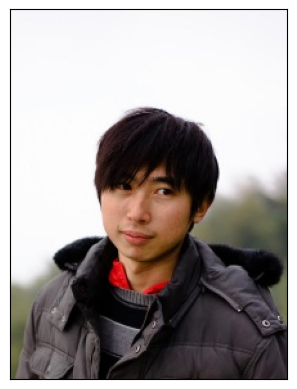

In [31]:

idx = '0'
img_path = '../dataset/train/img/'+idx+'.jpg'
trimap_path = '../dataset/train/trimaps/'+idx+'.png'
mask_path = '../dataset/train/mask/'+idx+'.png'

t=0.6 #Threshold
sample = Image.open(img_path)
trimap = Image.open(trimap_path)
mask = Image.open(mask_path)

plt.xticks([])
plt.yticks([])
plt.imshow(sample)
# plt.imshow(trimap, cmap='gray')
# plt.imshow(mask, cmap='gray')

## U-Net

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt_path = '../checkpoints/final_model.pth'

state_dict = torch.load(ckpt_path, weights_only=False)
model = UNet(in_channels=3, out_channels=1)
model = torch.nn.DataParallel(model) #Weights Stored in DataParallel format
model.load_state_dict(state_dict)
model.to(device)
model.eval()
model = model.module #Combine model split up by DataParallel

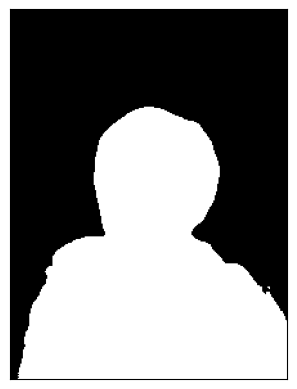

In [33]:
transform = transforms.ToTensor()
tensor_image = transform(sample).cuda()
output = model(tensor_image[None]).detach().cpu().numpy()

thresh = threshold(output[0][0], t)
plt.xticks([])
plt.yticks([])
plt.imshow(thresh, cmap='gray')

## ViT-Matte

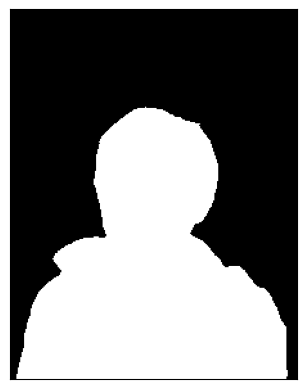

In [34]:
processor = AutoImageProcessor.from_pretrained("hustvl/vitmatte-base-distinctions-646")
model = VitMatteForImageMatting.from_pretrained("hustvl/vitmatte-base-distinctions-646")

model.to(device)

pixel_values = processor(images=sample, trimaps=trimap, return_tensors="pt").pixel_values
outputs = model(pixel_values.to(device))
outputs = outputs.alphas.flatten(0, 2).cpu().detach().numpy()

thresh = threshold(outputs, t)
plt.xticks([])
plt.yticks([])
plt.imshow(thresh, cmap='gray')

## Closed Form Alpha Matting

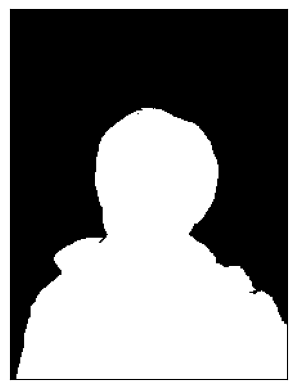

In [35]:
#output = estimate_alpha_knn(image, trimap)
image = load_image(img_path)
trimap = load_image(trimap_path)
output = estimate_alpha_cf(image, trimap)

thresh = threshold(output, t)
plt.xticks([])
plt.yticks([])
plt.imshow(thresh, cmap='gray')

## KNN Matting

0.5838778018951416


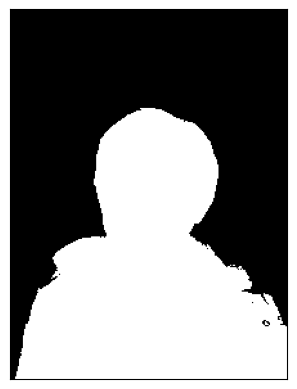

In [36]:
image = load_image(img_path)
trimap = load_image(trimap_path)
import time
start = time.time()
output = estimate_alpha_knn(image, trimap)
print(time.time()-start)
thresh = threshold(output, t)
plt.xticks([])
plt.yticks([])
plt.imshow(thresh, cmap='gray')